Handwritten Digit Recognition using CNN (MNIST Dataset)

The MNIST dataset is a famous benchmark dataset in deep learning and computer vision. It consists of 70,000 grayscale images of handwritten digits (0–9), each of size 28×28 pixels.

Training set: 60,000 images

Test set: 10,000 images

Image type: Grayscale (1 color channel)

Classes: 10 (digits 0 through 9)

It is widely used to teach and test image classification models, especially for Convolutional Neural Networks (CNNs), because it is simple, well-labeled, and ideal for beginners to understand how image recognition works.

In [19]:
import numpy as np 
import matplotlib.pyplot as plt 
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [2]:
# load the mnist dataset
# x_train, x_test, y_train, y_test = mnist.load_data() - not written because mnist.load_data(), returns 2 goups only
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print('training data shape', x_train.shape)
print('training data shape', y_train.shape)
print('testing data shape', x_test.shape)
print('testing data shape', y_test.shape)

training data shape (60000, 28, 28)
training data shape (60000,)
testing data shape (10000, 28, 28)
testing data shape (10000,)


In [3]:
# reshaping the image to include channel dimension(grayscle = 1)
x_train = x_train.reshape((x_train.shape[0], 28,28,1))
x_test = x_test.reshape((x_test.shape[0], 28, 28,1))
# Before: (60000, 28, 28), After: (60000, 28, 28, 1)

In [4]:
# normalizing the pixel - the images may be of diff pixel max value of pixel is 255 so here we are converting the pixels to a range of 0 to 1
x_train = x_train.astype('float32') / 225 # float32 means converting the pixel values into decimal numbers
x_test = x_test.astype('float32') / 225

In [ ]:
print(y_train) # These are the actual answers/labels for the images.
#Image 1 → 5, Image 2 → 0, Image 3 → 4

[5 0 4 ... 5 6 8]


In [6]:
# one hot to encode the labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
print('x_train shape', x_train.shape)
print('y_train shape', y_train.shape)
# This line converts the digit labels (like 0–9) into one-hot vectors — meaning each label becomes a list of 10 values where only the correct digit’s position is 1 and the rest are 0 — so the CNN can easily classify them.
# picture 

x_train shape (60000, 28, 28, 1)
y_train shape (60000, 10)


In [ ]:
print(y_train) # So the correct digit's(image(0-9)) position becomes 1, and all other positions become 0.

[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]


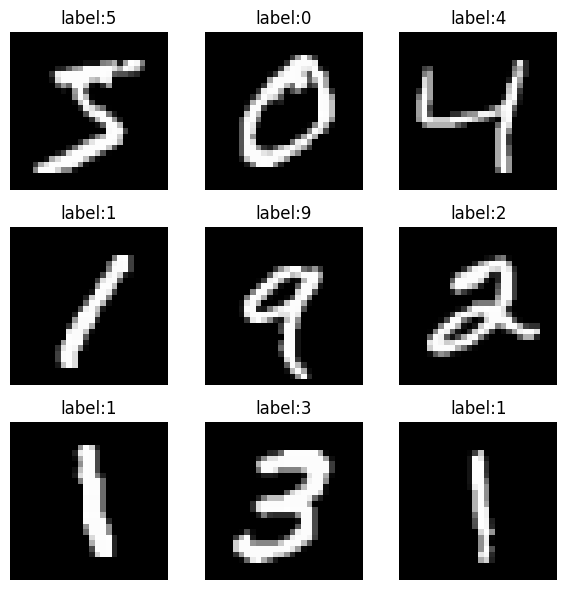

In [ ]:
# visualize
plt.figure(figsize = (6,6)) # figsize=(6,6) means the figure is approximately 6 × 6 inches.
for i in range(9): # So we will display 9 images.
    plt.subplot(3,3, i+1) # 3 rows, 3 columns, i+1 = which position we're currently filling
    plt.imshow(x_train[i].reshape(28, 28), cmap = 'gray') # image show
    # x_train[i] - Gets one image. Image currently has: 28 × 28 × 1, reshape ing it to (28 * 28)
    plt.title(f'label:{np.argmax(y_train[i])}')
    # For example, if the original label was 5, it became(after encoding): [0,0,0,0,0,1,0,0,0,0]
    # argmax means: Find the position (index) where the largest value is located.
    plt.axis('off')
plt.tight_layout() # Makes the 9 images fit nicely without overlapping.
plt.show()

In [ ]:
# define the model
model = Sequential([Conv2D(32, kernel_size = (3, 3), activation = 'relu', input_shape = (28,28,1)), MaxPooling2D(pool_size=(2,2)), Conv2D(64, kernel_size = (3,3), activation = 'relu'), MaxPooling2D(pool_size = (2,2)), Flatten(), Dense(128, activation = 'relu'), Dropout(0.5), Dense(10, activation= 'softmax')])
model # dropout - to reduce overfitting
# Run these layers one after another in the given order, So the output of one layer becomes the input of the next layer.
# The CNN will learn 32 different filters.These filters can learn things like: edges, curves, lines, corners, small patterns, like this anything
# relu - non-linear pattterns lerans
# max pooling - Keep the strongest/most important signal.
# flatten - 2D to 3D
# Dense(128) - It takes all the features from Flatten() and combines them to help decide which digit the image represents.
# Final dense - This is the output layer,  10 output classes for digits 0–9

c:\Users\POOJA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Sequential name=sequential, built=True>

This code builds a Convolutional Neural Network (CNN) using Keras’s Sequential API for recognizing handwritten digits from the MNIST dataset.

Here’s what each layer does:

Conv2D (32 filters): Detects basic features like edges and curves.

MaxPooling2D: Reduces image size, keeping important features while lowering computation.

Conv2D (64 filters): Learns more complex features.

MaxPooling2D: Further reduces spatial dimensions.

Flatten: Converts 2D feature maps into a 1D vector for the dense layers.

Dense (128 neurons): Learns high-level patterns.

Dropout (0.5): Prevents overfitting by randomly turning off half of the neurons during training.

Dense (10 neurons, softmax): Outputs probabilities for the 10 digit classes (0–9).

Result: This CNN can automatically learn to recognize handwritten digits with high accuracy.

In [ ]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
# The optimizer decides how the model should change its weights to improve its predictions.
# Loss tells us how wrong the model's prediction is.
# metrics = ['accuracy'] - While training, also show me how many predictions are correct.

In [17]:
# train the model
history = model.fit(x_train, y_train, epochs = 5, batch_size = 128, validation_split = 0.1, verbose = 2)

Epoch 1/5
422/422 - 17s - 39ms/step - accuracy: 0.9071 - loss: 0.3037 - val_accuracy: 0.9822 - val_loss: 0.0612
Epoch 2/5
422/422 - 13s - 31ms/step - accuracy: 0.9707 - loss: 0.0976 - val_accuracy: 0.9860 - val_loss: 0.0512
Epoch 3/5
422/422 - 13s - 30ms/step - accuracy: 0.9782 - loss: 0.0735 - val_accuracy: 0.9880 - val_loss: 0.0405
Epoch 4/5
422/422 - 13s - 31ms/step - accuracy: 0.9826 - loss: 0.0588 - val_accuracy: 0.9903 - val_loss: 0.0349
Epoch 5/5
422/422 - 12s - 28ms/step - accuracy: 0.9851 - loss: 0.0514 - val_accuracy: 0.9908 - val_loss: 0.0331


This code trains the CNN on the training data for 5 rounds (epochs), using batches of 128 images at a time, and keeps aside 10% of the training data to check how well the model performs on unseen data during training.

In [18]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test Accuracy, {test_acc:.4f}')
print(f'Test Loss, {test_loss:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9905 - loss: 0.0290
Test Accuracy, 0.9905
Test Loss, 0.0290


In [ ]:
y_pred = model.predict(x_test) # giving the test images to the trained model.
y_pred_classes = np.argmax(y_pred, axis = 1) # predicted
y_true = np.argmax(y_test, axis = 1) # actual value
print(y_pred_classes)
print(y_true)
print('classification_report', classification_report(y_true, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
[7 2 1 ... 4 5 6]
[7 2 1 ... 4 5 6]
classification_report               precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



* y_pred = model.predict(x_test) - the model gives probabilities, not directly the digit.
 * y_pred =
[0.01, 0.02, 0.01, 0.03, 0.01, 0.88, 0.01, 0.01, 0.01, 0.01]
 * y_pred_classes = np.argmax(y_pred, axis=1) - to convert - [0.01, 0.02, 0.01, 0.03, 0.01, 0.88, ...] into: 5, argmax - highest value.
* y_test = to_categorical(y_test) - So the actual answer 5 the with axis = 1 - the ouput was again changed to was changed into: [0,0,0,0,0,1,0,0,0,0]


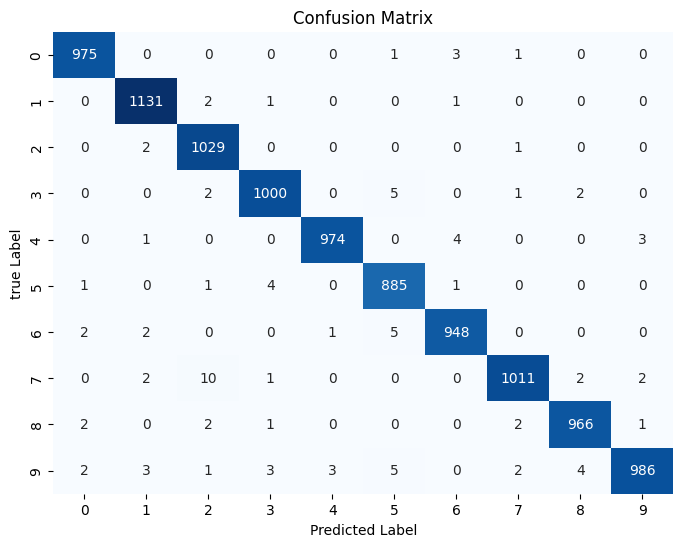

In [ ]:
# confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize = (8,6))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Blues', cbar = False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('true Label')
plt.show()
# annot = True - Show the numbers inside each box.
# fit = 'd' - Means display the numbers as whole integers.
# cbar=False - removes the color scale bar on the side.

Prediction for test data

In [25]:
# prediction for test images
predictions = model.predict(x_test)
predicted_class = np.argmax(predictions, axis =1)
true_class = np.argmax(y_test, axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


The code finds which digit the model thinks each test image is by choosing the number with the highest prediction score and compares it with the real answer.

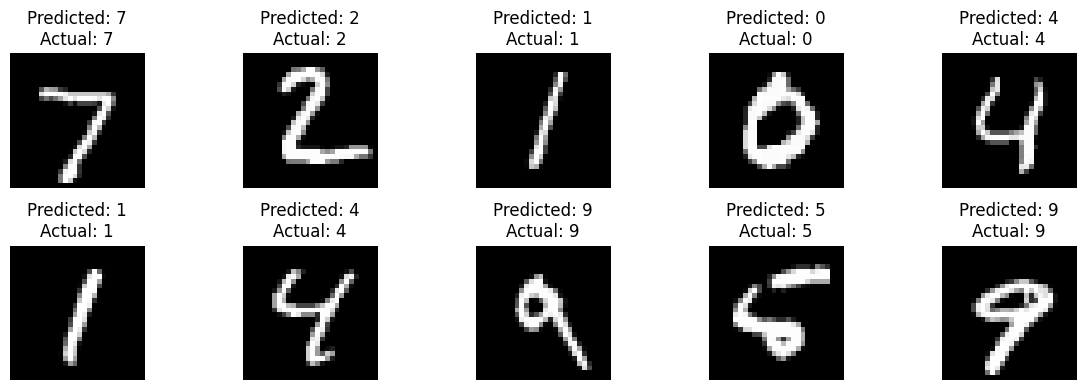

In [ ]:
# plott the first 10 test(x_test) images with predictions
plt.figure(figsize = (12,4))
for i in range(10):
    plt.subplot(2,5, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap = 'gray')
    plt.title(f'Predicted: {predicted_class[i]}\nActual: {true_class[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()
# This code shows 10 test images side by side, displaying each image’s predicted label
# and its actual label, so you can visually compare how well the CNN is performing on unseen data.

Prediction of single image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


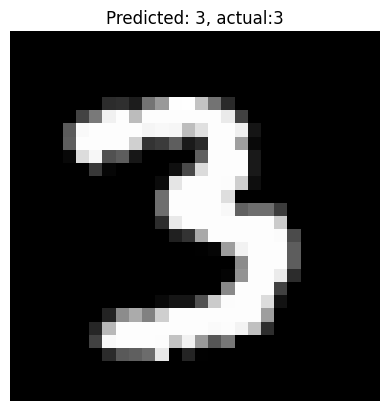

In [29]:
index = 500
single_image = x_test[index].reshape(1,28,28,1)

predict_single = np.argmax(model.predict(single_image))
actual_single = np.argmax(y_test[index])

plt.imshow(x_test[index].reshape(28,28,), cmap = 'grey')
plt.title(f'Predicted: {predict_single}, actual:{actual_single}')
plt.axis('off')
plt.show()